<a href="https://colab.research.google.com/github/shynin889-glitch/flight_price_prediction/blob/main/Shyni_FlightPrice_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fight  Price Prediction**

## Import Libraries

In [55]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/AI ML/flight_dataset-selected-columns.csv")
df

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50
...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,4107,9,4,2019,19,55
10679,Air India,Kolkata,Banglore,0,4145,27,4,2019,20,45
10680,Jet Airways,Banglore,Delhi,0,7229,27,4,2019,8,20
10681,Vistara,Banglore,New Delhi,0,12648,1,3,2019,11,30


## Adding null values

In [56]:
df['Destination'][0:4] = np.nan

/tmp/ipykernel_1881/3356468049.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Destination'][0:4] = np.nan
/tmp/ipykernel_1881/3356468049.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [57]:
df

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
0,IndiGo,Banglore,NaN,0,3897,24,3,2019,22,20
1,Air India,Kolkata,NaN,2,7662,1,5,2019,5,50
2,Jet Airways,Delhi,NaN,2,13882,9,6,2019,9,25
3,IndiGo,Kolkata,NaN,1,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50
...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,4107,9,4,2019,19,55
10679,Air India,Kolkata,Banglore,0,4145,27,4,2019,20,45
10680,Jet Airways,Banglore,Delhi,0,7229,27,4,2019,8,20
10681,Vistara,Banglore,New Delhi,0,12648,1,3,2019,11,30


## Finding the length of airline and year

In [58]:
len(df['Airline'].unique())

12

In [59]:
len(df['Year'].unique())

1

## Understanding the Data
Features (X):
- Airline
- Source
- Destination
- Total_stops
- Date
- Month
- Year
- Dep_hours
- Dep_min

Target (y):
- Price

In [60]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
0,IndiGo,Banglore,NaN,0,3897,24,3,2019,22,20
1,Air India,Kolkata,NaN,2,7662,1,5,2019,5,50
2,Jet Airways,Delhi,NaN,2,13882,9,6,2019,9,25
3,IndiGo,Kolkata,NaN,1,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50


In [61]:
df.tail()

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
10678,Air Asia,Kolkata,Banglore,0,4107,9,4,2019,19,55
10679,Air India,Kolkata,Banglore,0,4145,27,4,2019,20,45
10680,Jet Airways,Banglore,Delhi,0,7229,27,4,2019,8,20
10681,Vistara,Banglore,New Delhi,0,12648,1,3,2019,11,30
10682,Air India,Delhi,Cochin,2,11753,9,5,2019,10,55


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Airline      10683 non-null  object
 1   Source       10683 non-null  object
 2   Destination  10679 non-null  object
 3   Total_Stops  10683 non-null  int64 
 4   Price        10683 non-null  int64 
 5   Date         10683 non-null  int64 
 6   Month        10683 non-null  int64 
 7   Year         10683 non-null  int64 
 8   Dep_hours    10683 non-null  int64 
 9   Dep_min      10683 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 834.7+ KB


In [63]:
df[['Airline']]

,Airline
0,IndiGo
1,Air India
2,Jet Airways
3,IndiGo
4,IndiGo
...,...
10678,Air Asia
10679,Air India
10680,Jet Airways
10681,Vistara


In [64]:
df[df['Price'] > 30000]

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
396,Multiple carriers,Delhi,Cochin,1,36983,1,3,2019,12,50
657,Jet Airways Business,Banglore,New Delhi,1,52229,1,3,2019,5,45
1478,Jet Airways,Banglore,New Delhi,1,54826,18,3,2019,18,40
1629,Air India,Banglore,New Delhi,2,31783,1,3,2019,8,50
2099,Jet Airways,Banglore,New Delhi,1,36235,1,3,2019,14,5
2618,Jet Airways,Banglore,New Delhi,1,54826,18,3,2019,22,50
2693,Jet Airways,Banglore,New Delhi,1,35185,1,3,2019,18,40
2924,Jet Airways Business,Banglore,New Delhi,1,79512,1,3,2019,5,45
3700,Jet Airways,Banglore,New Delhi,1,31825,1,3,2019,22,50
5013,Jet Airways,Banglore,New Delhi,1,31825,1,3,2019,22,50


In [65]:
df[(df['Airline'] == 'Vistara') & (df['Price'] <= 4000)]

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
29,Vistara,Chennai,Kolkata,0,3687,15,6,2019,7,5
30,Vistara,Chennai,Kolkata,0,3687,18,6,2019,7,5
64,Vistara,Chennai,Kolkata,0,3687,24,5,2019,7,5
516,Vistara,Chennai,Kolkata,0,3687,27,5,2019,7,5
552,Vistara,Chennai,Kolkata,0,3739,21,3,2019,7,5
920,Vistara,Chennai,Kolkata,0,3687,21,6,2019,7,5
1092,Vistara,Chennai,Kolkata,0,3687,1,6,2019,7,5
1274,Vistara,Chennai,Kolkata,0,3739,27,3,2019,7,5
2466,Vistara,Chennai,Kolkata,0,3687,21,5,2019,7,5
2805,Vistara,Chennai,Kolkata,0,3687,27,6,2019,7,5


## Checking the Null Values

In [66]:
df.isnull().sum().sum()

np.int64(4)

In [67]:
df.isnull().sum()

,0
Airline,0
Source,0
Destination,4
Total_Stops,0
Price,0
Date,0
Month,0
Year,0
Dep_hours,0
Dep_min,0


## Filling the Null Values

In [68]:
df['Destination'] = df['Destination'].fillna('kerala')
df.head()


,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
0,IndiGo,Banglore,kerala,0,3897,24,3,2019,22,20
1,Air India,Kolkata,kerala,2,7662,1,5,2019,5,50
2,Jet Airways,Delhi,kerala,2,13882,9,6,2019,9,25
3,IndiGo,Kolkata,kerala,1,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50


## Finding the Average of Dep_hours

In [69]:
avg = df['Dep_hours'].mean()
avg

np.float64(12.490686136852943)

## Dropping the columns with null values

In [70]:
df = df.dropna(axis = "columns") #used to remove the columns with null values
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Date',
       'Month', 'Year', 'Dep_hours', 'Dep_min'],
      dtype='object')

## Sorting

In [71]:
sort = df.sort_values('Month',ascending=False)
sort.tail(1000)

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
4366,Jet Airways,Mumbai,Hyderabad,0,2228,18,3,2019,2,55
9632,Jet Airways,Banglore,New Delhi,1,27992,1,3,2019,5,45
9635,Jet Airways,Delhi,Cochin,1,12242,27,3,2019,15,5
9644,Air India,Mumbai,Hyderabad,0,2050,27,3,2019,13,55
515,Air India,Delhi,Cochin,2,22096,3,3,2019,22,0
...,...,...,...,...,...,...,...,...,...,...
1836,IndiGo,Chennai,Kolkata,0,7295,3,3,2019,19,35
1837,Air India,Banglore,New Delhi,1,9292,9,3,2019,17,0
7,Jet Airways,Banglore,New Delhi,1,22270,1,3,2019,8,0
6,Jet Airways,Banglore,New Delhi,1,11087,12,3,2019,18,55


## Group By

In [72]:
print(df['Source'].unique())

['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']


In [73]:
group_place = df.groupby('Source')
group_city = group_place.get_group('Banglore')
total_price = group_city['Price'].sum()
total_price

np.int64(17614369)

## Average price of each airlines

In [74]:
avg_price = df.groupby("Airline")["Price"].mean()
avg_price

,Price
Airline,
Air Asia,5590.260188
Air India,9611.210616
GoAir,5861.056701
IndiGo,5673.682903
Jet Airways,11643.923357
Jet Airways Business,58358.666667
Multiple carriers,10902.678094
Multiple carriers Premium economy,11418.846154
SpiceJet,4338.284841


# Graph:

## Bar graph

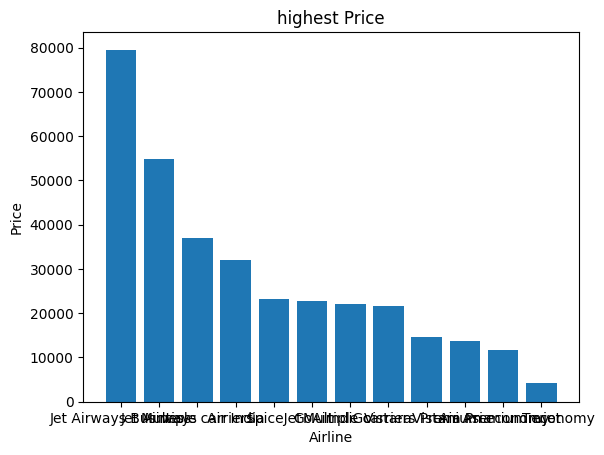

In [75]:
import matplotlib.pyplot as plt
high_duration = df[['Airline','Price']].sort_values('Price',ascending=False)
plt.bar(high_duration['Airline'],high_duration['Price'])
plt.title('highest Price')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.show()

## pie chart

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

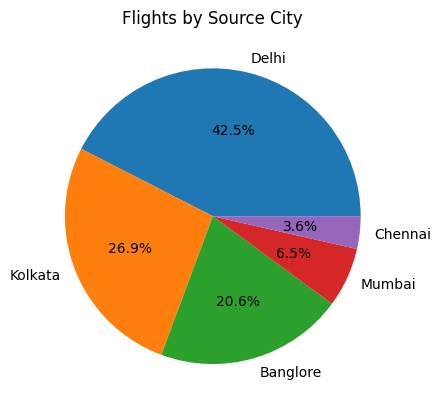

In [77]:
Source_count = df['Source'].value_counts()
plt.pie(Source_count,labels=Source_count.index,autopct='%1.1f%%')
plt.title('Flights by Source City')
plt.show()

## Scatter graph

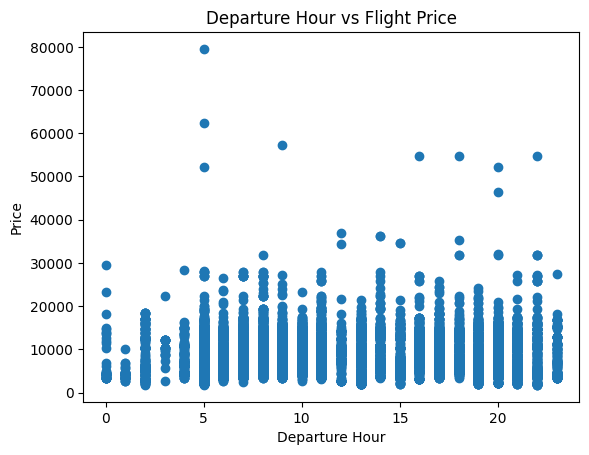

In [78]:
import matplotlib.pyplot as plt
plt.scatter(df['Dep_hours'], df['Price'])
plt.title('Departure Hour vs Flight Price')
plt.xlabel('Departure Hour')
plt.ylabel('Price')
plt.show()

## histogram

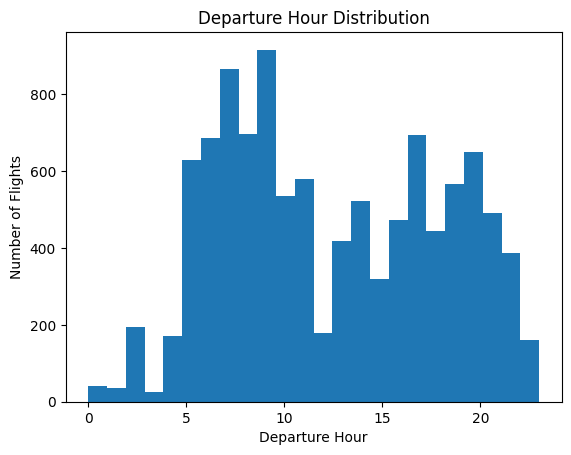

In [79]:
import matplotlib.pyplot as plt
plt.hist(df['Dep_hours'], bins=24)
plt.title('Departure Hour Distribution')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.show()

In [80]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Date',
       'Month', 'Year', 'Dep_hours', 'Dep_min'],
      dtype='object')

## Training the model
## Data preprocessing and feature encoding

In [81]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Airline'] = le.fit_transform(df['Airline'])
ab = LabelEncoder()
df['Source'] = le.fit_transform(df['Source'])
cd = LabelEncoder()
df['Destination'] = le.fit_transform(df['Destination'])
ef = LabelEncoder()
df.head()

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min
0,3,0,6,0,3897,24,3,2019,22,20
1,1,3,6,2,7662,1,5,2019,5,50
2,4,2,6,2,13882,9,6,2019,9,25
3,3,3,6,1,6218,12,5,2019,18,5
4,3,0,5,1,13302,1,3,2019,16,50


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Airline      10683 non-null  int64
 1   Source       10683 non-null  int64
 2   Destination  10683 non-null  int64
 3   Total_Stops  10683 non-null  int64
 4   Price        10683 non-null  int64
 5   Date         10683 non-null  int64
 6   Month        10683 non-null  int64
 7   Year         10683 non-null  int64
 8   Dep_hours    10683 non-null  int64
 9   Dep_min      10683 non-null  int64
dtypes: int64(10)
memory usage: 834.7 KB


## Select Features and Target Variable

In [83]:
x = df[['Airline', 'Source', 'Destination', 'Total_Stops','Date','Month', 'Year', 'Dep_hours', 'Dep_min']]
y = df['Price']
y.head()
x.head()

,Airline,Source,Destination,Total_Stops,Date,Month,Year,Dep_hours,Dep_min
0,3,0,6,0,24,3,2019,22,20
1,1,3,6,2,1,5,2019,5,50
2,4,2,6,2,9,6,2019,9,25
3,3,3,6,1,12,5,2019,18,5
4,3,0,5,1,1,3,2019,16,50


## Split Datasets into Training and Testing Sets and Verifying Training and Testing Records

In [84]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=42)
print('training records:',len(x_train))
print('testing records:',len(x_test))

training records: 8546
testing records: 2137


## training the multiple linear regression model and display model parameters

In [85]:
model=LinearRegression()
model.fit(x_train,y_train)
print('slope:',model.coef_[0])
print('intercept:',model.intercept_)

slope: 182.0904974018436
intercept: 8257.568685010123


In [86]:
x_test

,Airline,Source,Destination,Total_Stops,Date,Month,Year,Dep_hours,Dep_min
6076,4,3,0,1,18,5,2019,5,45
3544,2,2,1,1,3,6,2019,10,35
7313,4,3,0,1,1,5,2019,14,5
5032,3,1,4,0,24,5,2019,14,45
2483,4,2,1,1,21,5,2019,22,50
...,...,...,...,...,...,...,...,...,...
9797,6,2,1,1,27,6,2019,8,0
9871,8,3,0,0,6,3,2019,17,15
10063,0,2,1,1,21,4,2019,7,55
7623,3,0,2,0,9,4,2019,8,30


## predict price on test data

In [87]:
y_pred = model.predict(x_test)
print(y_pred)

[ 8466.09473575  9432.63557807 10573.30748733 ...  8359.06821777
  6255.85804236  9282.95461006]


## predict price for new flight

In [88]:
model.predict([[4,3,1,1,6,5,2019,8,50]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9586.58917076])

## Evaluate model performance


In [89]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print('mae:',mae)
print('mse:',mse)
print('r2:',r2)

mae: 2505.1083042641635
mse: 12224793.828002298
r2: 0.4223769875721681


# Conclusion

The Flight Price Prediction model was successfully developed using Multiple Linear Regression. The model was trained using features such as Airline, Source, Destination, Total Stops, Date, Month, Year, Departure Hour, and Departure Minute to predict flight ticket prices.

The performance of the model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. The model achieved an MAE of 2505.11, an MSE of 12,224,793.83, and an R² Score of 0.4224. This indicates that the model explains approximately 42.24% of the variation in flight prices.

The results show that Multiple Linear Regression can be used for flight price prediction, although the prediction accuracy can be further improved by using additional features or more advanced machine learning algorithms.